# 04 - 2.5D Neighbouring-Slice Index for Gold-Labelled Studies

This corrected notebook creates previous/current/next slice triplets for the **complete gold-labelled studies only**.

Important: this notebook assumes `03_preprocessing` has already been corrected and rerun for all complete gold-labelled studies, not `train.head(500)`.

It intentionally avoids printing thousands of `.npy` paths. The final output is concise and repository-friendly.

**Inputs needed:**
- Original RSNA dataset
- Corrected notebook 03 output containing `processed_metadata.csv` and `processed_data/` for all complete gold studies

**Outputs:**
- `/kaggle/working/2p5d_index.csv`
- `/kaggle/working/2p5d_sample_preview.png`

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
WORK_DIR = "/kaggle/working"

train = pd.read_csv(DATA_DIR + "/train.csv")
train_series = pd.read_csv(DATA_DIR + "/train_series.csv")

label_cols = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

gold_train = train.dropna(subset=label_cols).copy().reset_index(drop=True)
gold_study_ids = set(gold_train["StudyInstanceUID"])

print("Total train studies:", len(train))
print("Complete gold-labelled studies:", len(gold_train))

Total train studies: 4407
Complete gold-labelled studies: 58


In [3]:
# Auto-detect processed_metadata.csv from corrected notebook 03 output.
# Add notebook 03 output as Kaggle input before running this notebook.

def find_file(filename):
    matches = []
    for root, dirs, files in os.walk("/kaggle/input"):
        if filename in files:
            matches.append(os.path.join(root, filename))
    return matches

metadata_matches = find_file("processed_metadata.csv")

print("processed_metadata.csv candidates:")
for path in metadata_matches:
    print(" -", path)

if not metadata_matches:
    raise FileNotFoundError(
        "processed_metadata.csv not found. Add corrected 03_preprocessing output as input."
    )

# Prefer a preprocessing notebook output if multiple candidates exist.
preferred = [p for p in metadata_matches if "03" in p or "preprocess" in p.lower()]
processed_metadata_path = preferred[0] if preferred else metadata_matches[0]
PREPROCESS_DIR = os.path.dirname(processed_metadata_path)

print("Using processed_metadata_path:", processed_metadata_path)
print("Using PREPROCESS_DIR:", PREPROCESS_DIR)

processed_metadata = pd.read_csv(processed_metadata_path)
print("Processed metadata shape before filtering:", processed_metadata.shape)
display(processed_metadata.head())

processed_metadata.csv candidates:
 - /kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_metadata.csv
Using processed_metadata_path: /kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_metadata.csv
Using PREPROCESS_DIR: /kaggle/input/notebooks/shambhavisinha254/03-58-studies
Processed metadata shape before filtering: (336, 10)


,StudyInstanceUID,SeriesInstanceUID,Anatomical_Plane,Fluid_Sensitive,Fat_Suppression,File_Path,Num_Slices,Height,Width,DType
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,Sagittal,0,0,/kaggle/working/processed_data/1.2.826.0.1.368...,36,224,224,float16
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.12451507871565834868...,Coronal,0,0,/kaggle/working/processed_data/1.2.826.0.1.368...,30,224,224,float16
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,Coronal,1,1,/kaggle/working/processed_data/1.2.826.0.1.368...,30,224,224,float16
3,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,Sagittal,1,1,/kaggle/working/processed_data/1.2.826.0.1.368...,36,224,224,float16
4,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,Axial,1,1,/kaggle/working/processed_data/1.2.826.0.1.368...,32,224,224,float16


In [5]:
required_cols = [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "Anatomical_Plane",
    "Fluid_Sensitive",
    "Fat_Suppression",
    "File_Path",
    "Num_Slices"
]

missing = [c for c in required_cols if c not in processed_metadata.columns]
if missing:
    raise ValueError("Missing columns in processed_metadata: " + str(missing))

# Fix File_Path if it still points to /kaggle/working from notebook 03.
processed_metadata["File_Path"] = processed_metadata["File_Path"].astype(str).str.replace(
    "/kaggle/working",
    PREPROCESS_DIR,
    regex=False
)

# Keep only complete gold-labelled studies.
processed_metadata = processed_metadata[
    processed_metadata["StudyInstanceUID"].isin(gold_study_ids)
].copy().reset_index(drop=True)

processed_gold_ids = set(processed_metadata["StudyInstanceUID"].unique())
missing_gold_ids = sorted(gold_study_ids - processed_gold_ids)

print("Processed metadata shape after gold filtering:", processed_metadata.shape)
print("Gold studies represented in processed metadata:", len(processed_gold_ids))
print("Missing gold studies:", len(missing_gold_ids))

if missing_gold_ids:
    print("First missing gold studies:", missing_gold_ids[:10])
    raise ValueError(
        "Corrected 03 output does not contain all complete gold-labelled studies. "
        "Rerun 03 after replacing train.head(500) with all gold-labelled studies."
    )

# Check that at least first few .npy files exist without printing all paths.
exist_check = processed_metadata["File_Path"].head(20).apply(os.path.exists)
print("First 20 File_Path exist:", bool(exist_check.all()))
if not exist_check.all():
    display(processed_metadata.loc[~exist_check, ["StudyInstanceUID", "SeriesInstanceUID", "File_Path"]].head())
    raise FileNotFoundError("Some processed .npy paths do not exist after path rewrite.")

Processed metadata shape after gold filtering: (336, 10)
Gold studies represented in processed metadata: 58
Missing gold studies: 0
First 20 File_Path exist: True


In [6]:
# Concise audit: no massive path listing.

summary = {
    "processed_gold_studies": processed_metadata["StudyInstanceUID"].nunique(),
    "processed_series": len(processed_metadata),
    "total_slices": int(processed_metadata["Num_Slices"].sum()),
    "min_slices_per_series": int(processed_metadata["Num_Slices"].min()),
    "median_slices_per_series": float(processed_metadata["Num_Slices"].median()),
    "max_slices_per_series": int(processed_metadata["Num_Slices"].max())
}

print(summary)
print("Series by anatomical plane:")
print(processed_metadata["Anatomical_Plane"].value_counts())

{'processed_gold_studies': 58, 'processed_series': 336, 'total_slices': 10528, 'min_slices_per_series': 11, 'median_slices_per_series': 30.0, 'max_slices_per_series': 320}
Series by anatomical plane:
Anatomical_Plane
Sagittal    136
Coronal     119
Axial        81
Name: count, dtype: int64


In [7]:
def make_2p5d_index(metadata):
    rows = []

    for _, row in metadata.iterrows():
        num_slices = int(row["Num_Slices"])

        if num_slices < 1:
            continue

        for center_idx in range(num_slices):
            prev_idx = max(center_idx - 1, 0)
            next_idx = min(center_idx + 1, num_slices - 1)

            rows.append({
                "StudyInstanceUID": row["StudyInstanceUID"],
                "SeriesInstanceUID": row["SeriesInstanceUID"],
                "Anatomical_Plane": row["Anatomical_Plane"],
                "Fluid_Sensitive": row["Fluid_Sensitive"],
                "Fat_Suppression": row["Fat_Suppression"],
                "File_Path": row["File_Path"],
                "Num_Slices": num_slices,
                "Prev_Slice_Index": prev_idx,
                "Center_Slice_Index": center_idx,
                "Next_Slice_Index": next_idx
            })

    return pd.DataFrame(rows)

index_2p5d = make_2p5d_index(processed_metadata)

print("2.5D index shape:", index_2p5d.shape)
print("2.5D gold studies:", index_2p5d["StudyInstanceUID"].nunique())
print("2.5D series:", index_2p5d["SeriesInstanceUID"].nunique())
display(index_2p5d.head())

2.5D index shape: (10528, 10)
2.5D gold studies: 58
2.5D series: 336


,StudyInstanceUID,SeriesInstanceUID,Anatomical_Plane,Fluid_Sensitive,Fat_Suppression,File_Path,Num_Slices,Prev_Slice_Index,Center_Slice_Index,Next_Slice_Index
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,0,0,1
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,0,1,2
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,1,2,3
3,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,2,3,4
4,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,Sagittal,0,0,/kaggle/input/notebooks/shambhavisinha254/03-5...,36,3,4,5


2.5D sample shape: (224, 224, 3)
Min: 0.0
Max: 1.0
NaN: 0


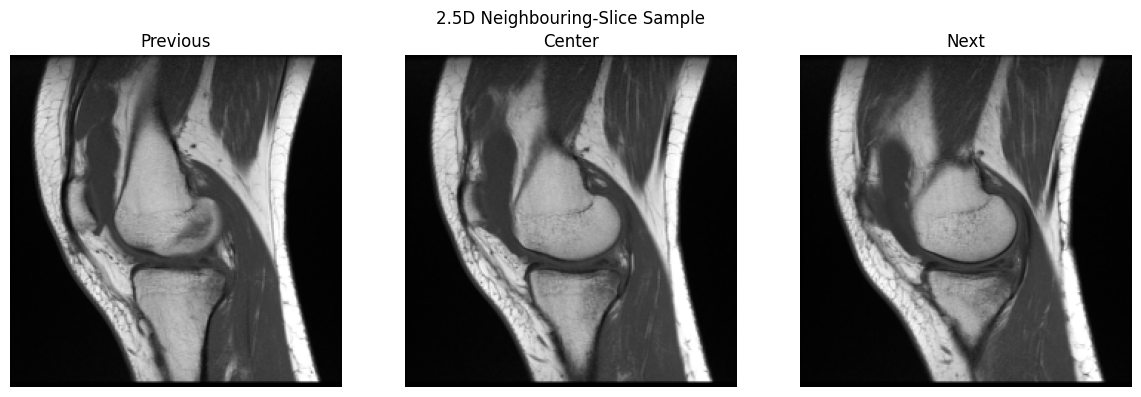

In [8]:
# Visual sanity check on one 2.5D sample.

def load_2p5d_sample(row):
    volume = np.load(row["File_Path"])

    prev_img = volume[int(row["Prev_Slice_Index"])]
    center_img = volume[int(row["Center_Slice_Index"])]
    next_img = volume[int(row["Next_Slice_Index"])]

    image_2p5d = np.stack([prev_img, center_img, next_img], axis=-1).astype(np.float32)
    return image_2p5d

sample_row = index_2p5d.iloc[len(index_2p5d) // 2]
sample_2p5d = load_2p5d_sample(sample_row)

print("2.5D sample shape:", sample_2p5d.shape)
print("Min:", sample_2p5d.min())
print("Max:", sample_2p5d.max())
print("NaN:", np.isnan(sample_2p5d).sum())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, title in enumerate(["Previous", "Center", "Next"]):
    axes[i].imshow(sample_2p5d[:, :, i], cmap="gray")
    axes[i].set_title(title)
    axes[i].axis("off")

plt.suptitle("2.5D Neighbouring-Slice Sample")
plt.tight_layout()
plt.savefig(WORK_DIR + "/2p5d_sample_preview.png", dpi=150)
plt.show()

In [9]:
out_path = WORK_DIR + "/2p5d_index.csv"
index_2p5d.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows:", len(index_2p5d))
print("Gold studies:", index_2p5d["StudyInstanceUID"].nunique())

Saved: /kaggle/working/2p5d_index.csv
Rows: 10528
Gold studies: 58


## Report Note

This notebook creates the 2.5D index only after verifying that the preprocessing output covers all complete gold-labelled studies. It avoids dumping large file lists into the notebook and produces a compact, reproducible artifact for study-level CV.